<a href="https://colab.research.google.com/github/leenAbdulaziz-glitch/Transformer-Project/blob/main/Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

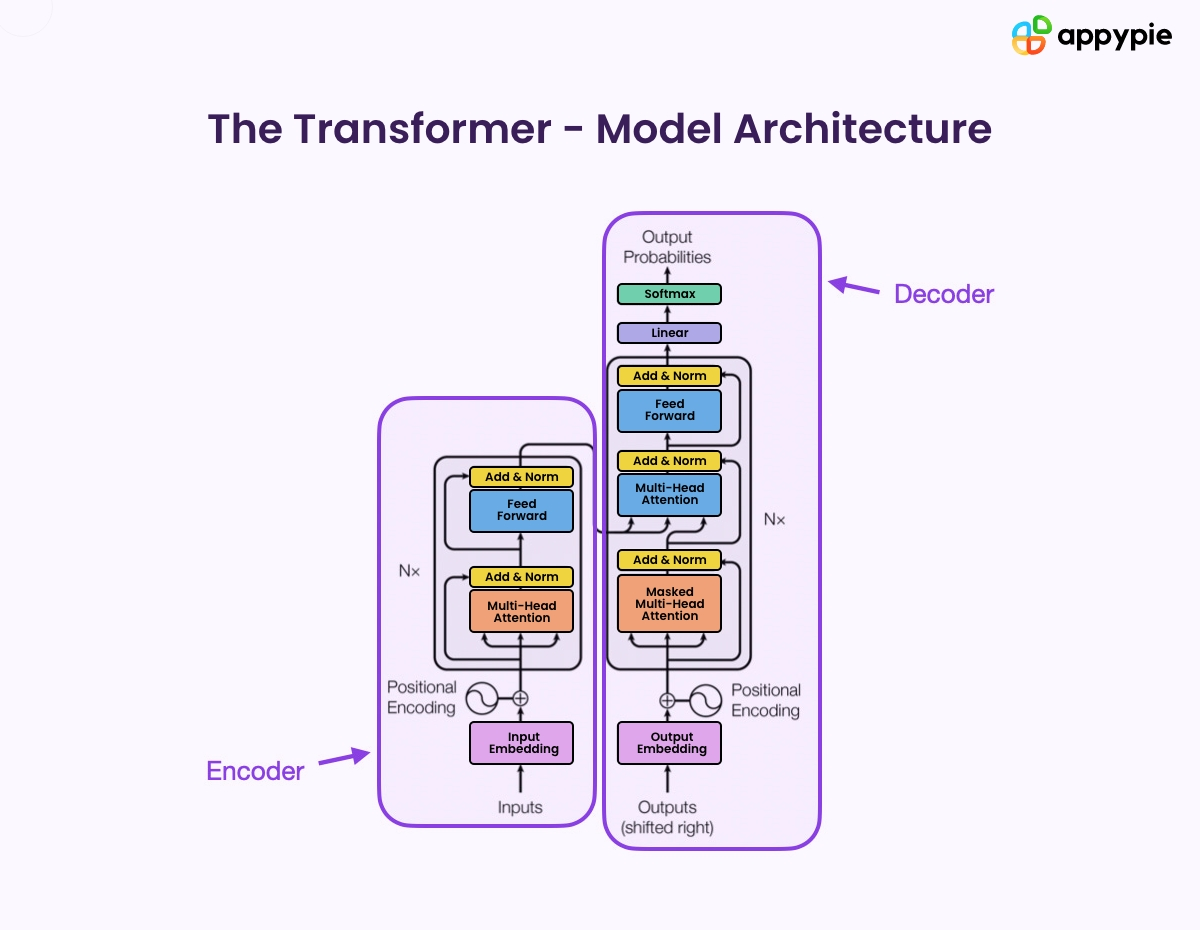

#Part 1 : Encoder



Attention :

Attention(Q,K,V)=softmax(QK^t/sqr(dk)​)V

Q (Query): الكلمة الحالية (وش تبغى تعرف؟)

K (Key): باقي الكلمات (وش عندهم؟)

V (Value): المعلومات الفعلية اللي بناخذها

كل كلمة "تناظر" باقي الكلمات وتشوف:

من اللي مهم لي؟


###Self-Attention

In [79]:
#Self-Attention
#conv the input to Q,K,V

import torch
import torch.nn as nn
import torch.nn.functional as F


#defined new layer inside pyTorch > means this block is reusbale inside the model
class SelfAttention(nn.Module):
  def __init__(self,embed_size): #embed_size = حجم التمثيل لكل كلمة > for example : each word conv to vector with 512 lingth
    super().__init__()
    self.embed_size = embed_size

    #convert the input to Q,K,V
    #3 Layers : لأننا نحتاج نحول نفس الإدخال إلى 3 تمثيلات مختلفة
    self.W_q = nn.Linear(embed_size ,embed_size)
    self.W_k = nn.Linear(embed_size ,embed_size)
    self.W_v = nn.Linear(embed_size ,embed_size)

  #conv the input x to Q,K,V > الشكل : (batch, seq_len, embed_size)
  def forward(self, Q_in, K_in, V_in, mask=None):
    Q = self.W_q(x)
    K = self.W_k(x)
    V = self.W_v(x)

    #calculate attention scores
    scores = torch.matmul(Q, K.transpose(-2,-1))#transpose : cuz we want to calculate each word X each word
    #= (batch, seq, seq) > كم كلمة i مهتمة بكلمة j

    #scaling
    #نقسم عشان ما نخلي القيم تكبروالسوفتماكس ما يصير انستيبل
    dk= Q.shape[-1] ** 0.5
    scores = scores / dk

    #softmax
    #conv each value to propabilty if we sum them we get 1
    attention = F.softmax(scores, dim=-1)

    #multi in V
    #نجمع المعلومات من الكلمات الأخرى
    #كل كلمة تأخذ:
    #جزء من كل كلمة ثانية
    #حسب الأهمية (attention)
    out = torch.matmul(attention, V)

    return out

##Multi-Head Attention

In [80]:
#Multi-Head Attention

class MultiHeadAttention(nn.Module):
  def __init__(self,embed_size,heads ):
    super().__init__()

    self.embed_size = embed_size
    self.heads = heads
    self.head_dim = embed_size // heads #نقسم prime mitex الى اجزاء من ال head عشان كل وحده منهم تشوف جزء من المعلومات

    assert self.head_dim * heads == embed_size # اشيك ان القسمه صحيح مايصير bug بعدين

    self.W_q = nn.Linear(embed_size ,embed_size)
    self.W_k = nn.Linear(embed_size ,embed_size)
    self.W_v = nn.Linear(embed_size ,embed_size)

    self.fc_out = nn.Linear(embed_size, embed_size)

  def forward(self, Q_in, K_in, V_in, mask=None):
    batch_size = Q_in.shape[0]
    Q = self.W_q(Q_in)
    K = self.W_k(K_in)
    V = self.W_v(V_in)

    # تقسيم إلى heads
    #before :(batch, seq, 512)

    Q = Q.view(batch_size, -1, self.heads, self.head_dim).transpose(1, 2)
    K = K.view(batch_size, -1, self.heads, self.head_dim).transpose(1, 2)
    V = V.view(batch_size, -1, self.heads, self.head_dim).transpose(1, 2)
    #after : (batch, heads, seq, head_dim) > عشان كل head يشتغل لحاله

    #attention
    scores = torch.matmul(Q, K.transpose(-2,-1)) #نفس الاتنشن لكن هنا كل هيد بشكل منفصل
    scores = scores / (self.head_dim ** 0.5)


    if mask is not None:
        scores = scores.masked_fill(mask == 0, float("-inf"))

    attention = torch.softmax(scores, dim=-1)

    #كل head ينتج نتيجة مختلفة
    out = torch.matmul(attention, V)

    #نجمع كل الـ heads في vector واحد
    out = out.transpose(1, 2).contiguous().view(batch_size, -1, self.embed_size)

    #Linear
    #نخلط معلومات الهيد مع بعض و النموذج يتعلم كيف يدمجهم
    out = self.fc_out(out)

    return out



##Encoder Layer

Multi-Head Attention

Add & Norm

Feed Forward

Add & Norm

In [81]:
class EncoderLayer(nn.Module):
  def __init__(self, embed_size, heads, forward_expansion):
    super().__init__()

    self.attention = MultiHeadAttention(embed_size, heads)#اساس الانكودر

    #نورملايز القيم
    self.norm1 = nn.LayerNorm(embed_size)
    self.norm2 = nn.LayerNorm(embed_size)

    #بعد مالكلمات تفاعلت مع بعض نحتاج معالجه اضافيه لكل كلمه
    #nn.ReLU() :inside the encoder we have Feed Foreaed Network and look like : Linear → ReLU → Linear
    #first Linear يكبر الابعاد
    #ReLU add non-linearity for learn hard pattren > f(x) = max(0, x)
    #second linear يرجع الحجم
    self.feed_forward = nn.Sequential(
        nn.Linear(embed_size, forward_expansion * embed_size),nn.ReLU(),nn.Linear(forward_expansion * embed_size, embed_size)
    )

  def forward(self,x):

    #Attention
    attention = self.attention(x , x ,x)

    #Residual + Norm
    #جمعنا الاكس مع الاتنشن وهذا اسمه Residual Connection
    #فايدته انه يمنع ضياع المعلومات ويساعد في تدريب الديب مودلز
    x = self.norm1(attention + x)

    #Feed Forward
    forward = self.feed_forward(x)

    #Residual + Norm
    out = self.norm2(forward + x)

    return out

#Encoder

In [82]:
class Encoder(nn.Module):
  def __init__(self, embed_size , num_layers , heads , forward_expansion):
    super().__init__()


    #نكرر لان الترانفسورمير مو لاير وحده بل ستاك من اللايرز
    self.layers = nn.ModuleList(
        [
            EncoderLayer(embed_size, heads , forward_expansion)
            for _ in range(num_layers)
        ]
    )

#كل مره: الفهم يتحسن اكثر
  def forward(self,x):
    for layer in self.layers:
      x = layer(x)
    return x

الـ Encoder يسوي 3 أشياء:

1. Attention

الكلمات تفهم علاقتها ببعض

2. Feed Forward

كل كلمة تعالج نفسها بعمق

3. Residual + Norm

يحافظ على الاستقرار

In [83]:
#Example :
x = torch.randn(2, 10, 512)  # batch=2, seq=10, embed=512

model = Encoder(embed_size=512, num_layers=2, heads=8, forward_expansion=4)

out = model(x)

print(out.shape)

torch.Size([2, 10, 512])


#Decoder

1️⃣ Masked Self-Attention

مثل الأنكودر… لكن مع Mask

فكرته اني ما اخليه يشوف المستقبل عشان يتوقع الكلمه الجايه

MaskedAttention(Q,K,V)=softmax(QK^t+M/(sqrt(dk))

M=mask ( نخلي قيم الاماكن الممنوعه سالب مالا نهايه )

2️⃣ Cross-Attention (الجسر)

يربط مخرجات الأنكودر بالديكودر

3️⃣ Feed Forward

نفس الأنكودر

##Masked Self-Attention

بدون mask:

المودل يشوف المستقبل أثناء التدريب

أثناء inference ما يقدر → distribution shift

النتيجة = model يخرب

In [84]:

#torch.tril(...)يخلي المصفوفه جزئها الثاني على فوق اصفار بحيث كل كلمه تشوف نفسها واللي قبلها بس
#1 0 0 0
#1 1 0 0
#1 1 1 0
#1 1 1 1
def genreate_mask(seq_len):
  mask = troch.tril(troch.ones(seq_len,seq_len))
  return mask

class MaskedSelfAttention(nn.Module):
  def __init__(self, embed_size ):
    super().__init__()

    self.embed_size = embed_size
    self.heads = heads
    self.head_dim = embed_size // heads


    self.W_q = nn.Linear(embed_size, embed_size)
    self.W_k = nn.Linear(embed_size, embed_size)
    self.W_v = nn.Linear(embed_size, embed_size)

    self.fc_out = nn.Linear(embed_size, embed_size)

  def forward(self, Q_in, K_in, V_in, mask=None):
    batch_size = Q_in.shape[0]

    Q = self.W_q(Q_in)
    K = self.W_k(K_in)
    V = self.W_v(V_in)

    Q = Q.view(batch_size, -1, self.heads, self.head_dim).transpose(1, 2)
    K = K.view(batch_size, -1, self.heads, self.head_dim).transpose(1, 2)
    V = V.view(batch_size, -1, self.heads, self.head_dim).transpose(1, 2)

    scores = torch.matmul(Q, K.transpose(-2, -1))
    scores = scores / (self.head_dim ** 0.5)


    #imporetnt LINE :
    #هنا نحط الماسك !!
    #make the 0 in the matrix -infinite

    if mask is not None:
       scores = scores.masked_fill(mask==0,float('-inf'))

    attention = torch.softmax(scores, dim=-1)

    out = torch.matmul(attention, V)

    out = out.transpose(1, 2).contiguous().view(batch_size, -1, self.embed_size)

    out = self.fc_out(out)

    return out

##Cross-Attention

Q من الديكودر

K و V من الأنكودر


decoder بدون encoder = يكتب كلام عام

decoder مع encoder = يكتب كلام مرتبط بالإدخال

In [85]:
#"الجسر" بين الفهم (Encoder) والتوليد (Decoder)

class CrossAttention(nn.Module):
  def __init__(self, embed_size):
    super().__init__()

    self.W_q = nn.Linear(embed_size, embed_size)
    self.W_k = nn.Linear(embed_size, embed_size)
    self.W_v = nn.Linear(embed_size, embed_size)

  def forward(self, x , enc_out):
     Q = self.W_q(x)
     K = self.W_k(enc_out)
     V = self.W_v(enc_out)

     scores = torch.matmul(Q, K.transpose(-2, -1))

     dk = Q.shape[-1] ** 0.5
     scores = scores / dk

     attention = torch.softmax(scores, dim=-1)

     out = torch.matmul(attention, V)

     return out


#Decoder Layer

In [86]:
class DecoderLayer(nn.Module):
  def __init__(self, embed_size,heads,forward_expansion):
    super().__init__()

    #يخلي النموذج يشوف الماضي فقط
    self.self_attention = MultiHeadAttention(embed_size,heads)
    self.norm1 = nn.LayerNorm(embed_size)#norm : نحافظ على المعلومات ونثبت القيم

    #ياخذ المعلومات من الانكودر
    self.cross_attention = MultiHeadAttention(embed_size,heads)
    self.norm2 = nn.LayerNorm(embed_size)

    self.feed_forward = nn.Sequential(
        nn.Linear(embed_size, forward_expansion * embed_size),nn.ReLU(),nn.Linear(forward_expansion * embed_size , embed_size)
    )
    self.norm3 = nn.LayerNorm(embed_size)

  def forward(self , x , enc_out = None , mask = None):
    #Mask Attention
    attn = self.self_attention(x,x,x,mask)
    x = self.norm1(attn + x)

    #Cross Attention
    if enc_out is not None:
            cross = self.cross_attention(x, enc_out, enc_out)
            x = self.norm2(cross + x)

    #Feed Forward
    forward = self.feed_forward(x)
    out = self.norm3(forward + x)

    return out


#Decoder

In [87]:
class Decoder(nn.Module):
    def __init__(self, embed_size, num_layers, heads, forward_expansion):
        super().__init__()

        self.layers = nn.ModuleList(
            [
                DecoderLayer(embed_size, heads, forward_expansion)
                for _ in range(num_layers)
            ]
        )

    def forward(self, x, enc_out= None, mask= None):
        for layer in self.layers:
            x = layer(x, enc_out, mask)
        return x

In [88]:
#Example :

x = torch.randn(2, 10, 512)
enc_out = torch.randn(2, 10, 512)

mask = torch.tril(torch.ones(10, 10)).unsqueeze(0).unsqueeze(0)

decoder = Decoder(512, 2, 8, 4)

out = decoder(x, enc_out, mask)

print(out.shape)

torch.Size([2, 10, 512])


#Dual-Mode Transformer: Text Generator with Context Awareness

## the idea :

Input:  "Artificial intelligence is"

Output: "Artificial intelligence is transforming the world"

Generation (GPT-style):

Input → Decoder → Output | used (Masked Self-Attention)

Context-Aware:
Context → Encoder → enc_out

Input → Decoder + enc_out → Output | used ( Encoder , Cross-Attention , Mask )


#Architecture :

1- Embedding Layer : tokens → vectors (512)

2- Encoder : context → Encoder → enc_out

3- Decoder

4- Output Layer :decoder output → Linear → vocab_size


Final :

          ┌──────────────┐
          │   Context    │
          └──────┬───────┘
                 ↓
             Encoder
                 ↓
              enc_out
                 ↓
    Input → Embedding → Decoder → Linear → Output
                    ↑
                 Mask


In [89]:
#small DATASET :

sentences = [
    "i love ai",
    "ai is powerful",
    "i love machine learning",
    "deep learning is amazing",
    "ai will change the world"
]


In [90]:
#Tokenizer
#conv : "i love ai" to > [1, 2, 3]


class Tokenizer :
  def __init__(self, sentences):
    self.word2idx = {}
    self.idx2word = {}

    self.build_vocab(sentences)

  def build_vocab(self, sentences):
    words = set()

    for sent in sentences:
      for word in sent.split():
        words.add(word)

    words = sorted(list(words))

    for i, word in enumerate(words):
      self.word2idx[word] = i + 1 #to make 0 padding or special token for futer
      self.idx2word[i + 1]= word

  def encode(self, sentence):
    return [self.word2idx[word]for word in sentence.split()]

  def decode(self, indices):
    return " ".join([self.idx2word[i] for i in indices])




In [91]:
#example :

tokenizer = Tokenizer(sentences)

print(tokenizer.word2idx)
print(tokenizer.encode("i love ai"))

{'ai': 1, 'amazing': 2, 'change': 3, 'deep': 4, 'i': 5, 'is': 6, 'learning': 7, 'love': 8, 'machine': 9, 'powerful': 10, 'the': 11, 'will': 12, 'world': 13}
[5, 8, 1]


In [92]:
#Training Pairs
#conv the data to TRAINING PAIRS :
#Input:  i love
#Target: love ai

def create_data(tokenizer, sentences):
  X = []
  Y = []

  for sent in sentences:
    encoded = tokenizer.encode(sent)

    for i in range(1, len(encoded)):
      X.append(encoded[:1])
      Y.append(encoded[1:i+1])

  return X,Y

#i love ai :
#X: [i]
#Y: [love]
#X: [i love]
#Y: [love ai]

In [93]:
#Padding
#مشكلتنا الجمل اطوالها مختلفه هنا حلها

def pad_sequences(sequences , max_len):
  padded = []

  for seq in sequences:
    seq = seq + [0] * (max_len - len(seq))

    padded.append(seq)

  return torch.tensor(padded)

In [94]:
#example

X, Y = create_data(tokenizer, sentences)

max_len = max(
    max(len(seq) for seq in X),max(len(seq) for seq in Y)
    )


X = pad_sequences(X, max_len)
Y = pad_sequences(Y, max_len)

In [95]:
#Embedding

embedding = nn.Embedding(len(tokenizer.word2idx)+1, 512)#+1 becuse index 0 = padding

In [96]:
#example :
x_emb = embedding(X)
print(x_emb.shape)

torch.Size([14, 4, 512])


In [97]:
#test
print(X[1])
print(Y[1])

tensor([5, 0, 0, 0])
tensor([8, 1, 0, 0])


we have : Tokens → Embedding → Decoder → Linear → Vocabulary Scores

transform do not understand the oreder of the sentence

##Position information
is the solution

In [98]:
class PositionalEncoding(nn.Module):
  def __init__(self, max_len,embed_size):
    super().__init__()
    self.encoding = torch.zeros(max_len, embed_size)#مصفوفة تخزن position vectors

    positions = torch.arange(0, max_len).unsqueeze(1)#give number for each position

    #sin/cos
    #يخلي كل position له pattern مميز
    #ويخلي النموذج يفهم العلاقات بين المواقع

    div_term = torch.exp(
          torch.arange(0, embed_size, 2) *
          (-torch.log(torch.tensor(10000.0)) / embed_size)
      )

    self.encoding[:, 0::2] = torch.sin(positions * div_term)
    self.encoding[:, 1::2] = torch.cos(positions * div_term)

  def forward(self, x):
    seq_len = x.shape[1]

    return x + self.encoding[:seq_len].to(x.device)


##Decoder Only GPT

In [99]:
class GPT(nn.Module):
    def __init__(self, vocab_size, embed_size, num_layers, heads, forward_expansion, max_len):
        super().__init__()
         #embedding : token → vector
        self.embedding = nn.Embedding(vocab_size, embed_size)
        #Positional Encoding : add info in order
        self.position = PositionalEncoding(max_len, embed_size)
        #يشغل: masked attention , feed forward
        self.decoder = Decoder(
            embed_size,
            num_layers,
            heads,
            forward_expansion
        )

        self.fc_out = nn.Linear(embed_size, vocab_size)
    #نمنعه يشوف المستقبل
    def generate_mask(self, seq_len):
        mask = torch.tril(torch.ones(seq_len, seq_len))
        return mask.unsqueeze(0).unsqueeze(0)

    def forward(self, x):
        seq_len = x.shape[1]

        mask = self.generate_mask(seq_len).to(x.device)

        x = self.embedding(x)

        x = self.position(x)

        out = self.decoder(x, enc_out=None, mask=mask)

        out = self.fc_out(out)

        return out

In [100]:
#bulid a Model
vocab_size = len(tokenizer.word2idx) + 1

model = GPT(
    vocab_size=vocab_size,
    embed_size=128,
    num_layers=2,
    heads=4,
    forward_expansion=4,
    max_len=max_len
)
out = model(X)

print(out.shape)

torch.Size([14, 4, 14])
